In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from time import sleep
import ipywidgets as widgets
%matplotlib widget

In [4]:
#Constants
NUM_PARTICLES = 500
DT = 0.1
FRAMES_RECORDED = 10

particle_positions = np.random.rand(NUM_PARTICLES,2)
particle_velocities = np.random.rand(NUM_PARTICLES,2) - 0.5
last_collisions = []
increase_temp = 1

def change_positions (particle_positions, particle_velocities):

    global last_collisions, FRAMES_RECORDED

    particle_positions = particle_positions + particle_velocities * DT * increase_temp

    particle_velocities[particle_positions[:, 0] < 0, 0]*=-1
    particle_velocities[particle_positions[:, 0] > 1, 0]*=-1
    particle_velocities[particle_positions[:, 1] < 0, 1]*=-1
    particle_velocities[particle_positions[:, 1] > 1, 1]*=-1


    last_collisions.append(np.sum(particle_positions[:, 0] < 0) + np.sum(particle_positions[:, 0] > 1) + np.sum(particle_positions[:, 1] < 0) + np.sum(particle_positions[:, 1] > 1))

    particle_positions[particle_positions[:, 0] < 0, 0]=0
    particle_positions[particle_positions[:, 0] > 1, 0]=1
    particle_positions[particle_positions[:, 1] < 0, 1]=0
    particle_positions[particle_positions[:, 1] > 1, 1]=1

    if len(last_collisions) > FRAMES_RECORDED:
        last_collisions.pop(0)

    return particle_positions, particle_velocities

def change_temperature(increase: bool = True):
    global increase_temp
    if increase:
        increase_temp += 0.2
    else:
        increase_temp = max(0.2, increase_temp - 0.2)

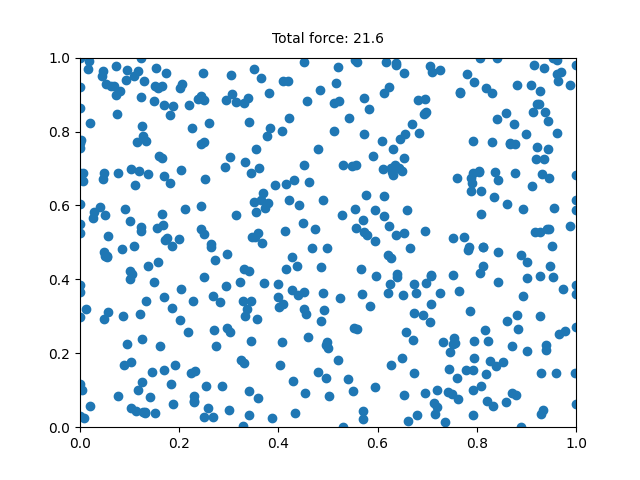

In [5]:
fig, ax = plt.subplots()
ax.set_xlim(0,1)
ax.set_ylim(0,1)
btn_up = widgets.Button(description="Increase Temp - 🔥")
btn_down = widgets.Button(description="Decrease Temp - ❄️")
collision_text = ax.text(0.5, 1.05, f'Total force: {sum(last_collisions)/FRAMES_RECORDED}', ha='center', va='center', transform=ax.transAxes)

scat = ax.scatter(particle_positions[:, 0], particle_positions[:, 1])

def on_up_clicked(b):
    change_temperature(increase=True)

def on_down_clicked(b):
    change_temperature(increase=False)

btn_up.on_click(on_up_clicked)
btn_down.on_click(on_down_clicked)

display(widgets.HBox([btn_up, btn_down]))

def update(frame):
    global particle_positions, particle_velocities, last_collisions, FRAMES_RECORDED
    particle_positions, particle_velocities = change_positions(particle_positions, particle_velocities)
    scat.set_offsets(particle_positions)
    collision_text.set_text(f'Total force: {sum(last_collisions)/FRAMES_RECORDED}')

    return scat, collision_text

ani = FuncAnimation(fig, update, frames=1800, interval=33, blit=True)